In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

## Loading files

Task: load the `gene_expression_data.csv` using pandas.
Maybe [this documentation](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) helps.

In [5]:
df = pd.read_csv(r"gene_expression_data.csv", sep=";")

In [4]:
df

,Gene,Healthy_Control_1,Healthy_Control_2,Disease_State_1,Disease_State_2,Post_Treatment_1,Post_Treatment_2
0,Gene0,5.248357,4.292315,2.699892,2.148309,4.665297,5.104763
1,Gene1,4.930868,4.789677,2.282069,6.143433,5.771680,5.735734
2,Gene2,5.323844,4.828643,2.705318,3.037047,5.168688,6.441012
3,Gene3,5.761515,4.598861,2.753500,6.550793,5.785299,6.172710
4,Gene4,4.882923,4.919357,8.157329,1.980384,5.118370,6.296593
...,...,...,...,...,...,...,...
95,Gene95,4.268243,5.192659,2.487806,3.057837,5.564611,6.051651
96,Gene96,5.148060,4.558071,6.193642,2.530060,5.554697,5.557114
97,Gene97,5.130528,5.076863,3.581582,7.060148,5.862883,5.575151
98,Gene98,5.002557,5.029104,8.926366,7.938085,5.740505,5.318194


# Numpy

In [6]:
df.describe()

,Healthy_Control_1,Healthy_Control_2,Disease_State_1,Disease_State_2,Post_Treatment_1,Post_Treatment_2
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,4.948077,5.011152,5.032448,5.010644,5.480685,5.474609
std,0.454084,0.476834,2.123254,2.099289,0.493920,0.525071
min,3.690127,4.040614,1.379366,1.966279,4.264178,4.151557
25%,4.699547,4.597170,3.027455,2.980796,5.172733,5.196834
50%,4.936522,5.042054,5.026973,4.984213,5.529913,5.432463
75%,5.202976,5.269085,7.096978,7.015064,5.786109,5.849947
max,5.926139,6.360085,8.926366,8.094901,6.722876,6.786680


## Calculate Basic Statistics for Healthy Controls

In [8]:
df["Healthy_Control_1"].values

array([5.24835708, 4.93086785, 5.32384427, 5.76151493, 4.88292331,
       4.88293152, 5.78960641, 5.38371736, 4.76526281, 5.27128002,
       4.76829115, 4.76713512, 5.12098114, 4.04335988, 4.13754108,
       4.71885624, 4.49358444, 5.15712367, 4.54598796, 4.29384815,
       5.73282438, 4.88711185, 5.0337641 , 4.28762591, 4.72780864,
       5.05546129, 4.42450321, 5.18784901, 4.69968066, 4.85415313,
       4.69914669, 5.92613909, 4.99325139, 4.47114454, 5.41127246,
       4.38957818, 5.1044318 , 4.02016494, 4.33590698, 5.09843062,
       5.36923329, 5.08568414, 4.94217586, 4.84944815, 4.260739  ,
       4.6400779 , 4.76968061, 5.52856111, 5.17180914, 4.11847992,
       5.16204198, 4.80745886, 4.661539  , 5.30583814, 5.51549976,
       5.46564006, 4.58039124, 4.84539381, 5.16563172, 5.48777256,
       4.76041288, 4.90717051, 4.44683251, 4.40189669, 5.40626291,
       5.67812001, 4.96399494, 5.50176645, 5.18081801, 4.67744012,
       5.1806978 , 5.76901828, 4.98208698, 5.78232183, 3.69012

In [9]:
# Calculate the mean expression of genes for Healthy_Control_1
mean_expression = np.mean(df["Healthy_Control_1"].values)

In [10]:
mean_expression

4.948076741302953

**Task**: Calculate the mean and standard deviation of gene expressions for both `Healthy_Control_1` and `Healthy_Control_2`.

In [11]:
np.mean(df["Healthy_Control_2"].values)

5.011152293524962

In [12]:
np.std(df["Healthy_Control_1"].values) ,np.std(df['Healthy_Control_2'])

(0.4518080883223148, 0.474444320255323)

In [13]:
np.std(df["Disease_State_1"].values)

2.1126107882895906

## Identify Differentially Expressed Genes:

Check which genes in `Disease_State_1` have an expression level greater than a certain threshold (e.g., 7).

In [15]:
df["Disease_State_1"].values > 7

array([False, False, False, False,  True, False, False, False,  True,
       False,  True, False, False, False,  True, False,  True,  True,
       False, False, False, False,  True, False, False, False,  True,
        True, False,  True,  True, False,  True, False, False, False,
        True,  True, False, False,  True,  True, False, False, False,
       False, False, False,  True,  True, False, False,  True, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False,  True, False,  True, False,  True, False, False,
        True, False, False, False,  True, False, False, False,  True,
        True])

In [16]:
overexpressed = df["Disease_State_1"].values > 7

In [19]:
df['Gene'][overexpressed]

4      Gene4
8      Gene8
10    Gene10
14    Gene14
16    Gene16
17    Gene17
22    Gene22
26    Gene26
27    Gene27
29    Gene29
30    Gene30
32    Gene32
36    Gene36
37    Gene37
40    Gene40
41    Gene41
48    Gene48
49    Gene49
52    Gene52
55    Gene55
69    Gene69
73    Gene73
83    Gene83
85    Gene85
87    Gene87
90    Gene90
94    Gene94
98    Gene98
99    Gene99
Name: Gene, dtype: object

**Task**: Identify genes from `Disease_State_2` that are underexpressed with a threshold of less than 3.

In [20]:
underexpressed = df["Disease_State_2"].values < 3
df['Gene'][underexpressed]

0      Gene0
4      Gene4
8      Gene8
9      Gene9
11    Gene11
21    Gene21
27    Gene27
31    Gene31
35    Gene35
40    Gene40
43    Gene43
46    Gene46
48    Gene48
54    Gene54
57    Gene57
60    Gene60
66    Gene66
74    Gene74
76    Gene76
79    Gene79
82    Gene82
83    Gene83
90    Gene90
91    Gene91
94    Gene94
96    Gene96
Name: Gene, dtype: object

In [26]:
overexpressed_1 = df['Disease_State_1'] > 7 #index of genes that are overexpressed
overexpressed_2 = df['Disease_State_2'] > 7 #index of genes that are overexpressed

combined = np.logical_and(overexpressed_1, overexpressed_2)
combined

df['Gene'][combined]

14    Gene14
26    Gene26
30    Gene30
52    Gene52
69    Gene69
73    Gene73
98    Gene98
Name: Gene, dtype: object

## Correlation between Samples

In [27]:
# Calculate the correlation between Healthy_Control_1 and Healthy_Control_2
correlation = np.corrcoef(df["Healthy_Control_1"].values, 
                          df["Healthy_Control_2"].values)[0, 1]

In [28]:
correlation

-0.1364222121700025

Calculate the correlation between `Disease_State_1` and `Post_Treatment_1`.

In [31]:
# Calculate the correlation between Healthy_Control_1 and Healthy_Control_2
correlation = np.corrcoef(df["Disease_State_1"].values, 
                          df["Post_Treatment_1"].values)[0, 1]

correlation

0.062017822064694285

# pandas

## Filtering Genes Based on Expression
Filter out genes with expressions greater than 6 in `Healthy_Control_1`.

In [45]:
filtered_genes = df[df["Healthy_Control_1"] > 5.5]

In [46]:
filtered_genes

,Gene,Healthy_Control_1,Healthy_Control_2,Disease_State_1,Disease_State_2,Post_Treatment_1,Post_Treatment_2
3,Gene3,5.761515,4.598861,2.753500,6.550793,5.785299,6.172710
6,Gene6,5.789606,5.943093,2.757883,3.814308,4.686229,5.005198
20,Gene20,5.732824,5.395516,6.531087,7.023490,5.917846,5.332108
31,Gene31,5.926139,5.034281,1.379366,2.734871,5.422161,6.063283
47,Gene47,5.528561,4.339772,6.881591,3.334836,4.995957,6.251996
54,Gene54,5.515500,5.146536,6.634817,2.309949,5.914703,4.796244
65,Gene65,5.678120,5.206390,3.153650,6.202786,5.624110,5.856499
67,Gene67,5.501766,5.948396,3.099530,3.684316,5.075078,5.312590
71,Gene71,5.769018,4.592095,6.461128,6.620434,5.261171,6.079665
73,Gene73,5.782322,5.170576,7.257524,7.048838,5.666831,5.807968


**Task**: Filter out genes that have an expression level below 4 in `Disease_State_2`.

In [47]:
df[df["Disease_State_2"] < 4]

,Gene,Healthy_Control_1,Healthy_Control_2,Disease_State_1,Disease_State_2,Post_Treatment_1,Post_Treatment_2
0,Gene0,5.248357,4.292315,2.699892,2.148309,4.665297,5.104763
2,Gene2,5.323844,4.828643,2.705318,3.037047,5.168688,6.441012
4,Gene4,4.882923,4.919357,8.157329,1.980384,5.118370,6.296593
6,Gene6,5.789606,5.943093,2.757883,3.814308,4.686229,5.005198
7,Gene7,5.383717,5.087289,3.424801,3.166157,5.524042,5.437107
8,Gene8,4.765263,5.128775,7.022786,2.470393,5.629861,5.527862
9,Gene9,5.271280,4.962777,2.807343,2.517538,5.047842,6.047096
10,Gene10,4.768291,4.040614,7.108229,3.033759,5.819296,4.653768
11,Gene11,4.767135,4.986743,3.140496,2.408371,4.669240,6.264775
15,Gene15,4.718856,5.150774,2.646165,3.183299,5.523699,4.672572


## Aggregating Data for Analysis
Calculate the average expression of genes across all conditions.

In [52]:
df.mean(axis=1, numeric_only=True)

0     4.026489
1     4.942244
2     4.584092
3     5.270446
4     5.225826
        ...   
95    4.437134
96    4.923607
97    5.381192
98    6.325802
99    5.243805
Length: 100, dtype: float64

In [ ]:
# axis=0 --> mean across rows, axis=1 --> mean across columns

In [54]:
df["Average_Expression"] = df.mean(axis=1, numeric_only=True)

In [53]:
df

,Gene,Healthy_Control_1,Healthy_Control_2,Disease_State_1,Disease_State_2,Post_Treatment_1,Post_Treatment_2,Average_Expression
0,Gene0,5.248357,4.292315,2.699892,2.148309,4.665297,5.104763,4.026489
1,Gene1,4.930868,4.789677,2.282069,6.143433,5.771680,5.735734,4.942244
2,Gene2,5.323844,4.828643,2.705318,3.037047,5.168688,6.441012,4.584092
3,Gene3,5.761515,4.598861,2.753500,6.550793,5.785299,6.172710,5.270446
4,Gene4,4.882923,4.919357,8.157329,1.980384,5.118370,6.296593,5.225826
...,...,...,...,...,...,...,...,...
95,Gene95,4.268243,5.192659,2.487806,3.057837,5.564611,6.051651,4.437134
96,Gene96,5.148060,4.558071,6.193642,2.530060,5.554697,5.557114,4.923607
97,Gene97,5.130528,5.076863,3.581582,7.060148,5.862883,5.575151,5.381192
98,Gene98,5.002557,5.029104,8.926366,7.938085,5.740505,5.318194,6.325802


**Task:**
Compute the maximum and minimum expression values of each gene across all samples.

In [55]:
df["Min_Expression"] = df.min(axis=1, numeric_only=True)
df["Max_Expression"] = df.max(axis=1, numeric_only=True)

In [57]:
df.tail()

,Gene,Healthy_Control_1,Healthy_Control_2,Disease_State_1,Disease_State_2,Post_Treatment_1,Post_Treatment_2,Average_Expression,Min_Expression,Max_Expression
95,Gene95,4.268243,5.192659,2.487806,3.057837,5.564611,6.051651,4.437134,2.487806,6.051651
96,Gene96,5.148060,4.558071,6.193642,2.530060,5.554697,5.557114,4.923607,2.530060,6.193642
97,Gene97,5.130528,5.076863,3.581582,7.060148,5.862883,5.575151,5.381192,3.581582,7.060148
98,Gene98,5.002557,5.029104,8.926366,7.938085,5.740505,5.318194,6.325802,5.002557,8.926366
99,Gene99,4.882706,4.428515,7.316960,3.751179,5.611942,5.471527,5.243805,3.751179,7.316960


## Sorting Data for Insights
Sort genes based on their expression levels in `Healthy_Control_1`

In [58]:
sorted_genes = df.sort_values(by="Healthy_Control_1", ascending=False)

In [59]:
sorted_genes

,Gene,Healthy_Control_1,Healthy_Control_2,Disease_State_1,Disease_State_2,Post_Treatment_1,Post_Treatment_2,Average_Expression,Min_Expression,Max_Expression
31,Gene31,5.926139,5.034281,1.379366,2.734871,5.422161,6.063283,4.426684,1.379366,6.063283
6,Gene6,5.789606,5.943093,2.757883,3.814308,4.686229,5.005198,4.666053,2.757883,5.943093
73,Gene73,5.782322,5.170576,7.257524,7.048838,5.666831,5.807968,6.122343,5.170576,7.257524
71,Gene71,5.769018,4.592095,6.461128,6.620434,5.261171,6.079665,5.797252,4.592095,6.620434
3,Gene3,5.761515,4.598861,2.753500,6.550793,5.785299,6.172710,5.270446,2.753500,6.550793
...,...,...,...,...,...,...,...,...,...,...
49,Gene49,4.118480,5.148492,7.252494,6.466190,5.324243,6.045753,5.725942,4.118480,7.252494
13,Gene13,4.043360,6.231621,6.673335,7.479635,4.894492,5.286559,5.768167,4.043360,7.479635
37,Gene37,4.020165,4.838969,7.032140,3.252023,5.283721,5.487937,4.985826,3.252023,7.032140
79,Gene79,4.006216,6.360085,3.221910,2.972226,5.688650,5.407549,4.609439,2.972226,6.360085


**Task**: Sort the dataframe based on the `Average_Expression` column (you would have added this in the previous task), but in ascending order.

In [61]:
sorted_genes = df.sort_values(by="Average_Expression", ascending=True)

In [62]:
sorted_genes

,Gene,Healthy_Control_1,Healthy_Control_2,Disease_State_1,Disease_State_2,Post_Treatment_1,Post_Treatment_2,Average_Expression,Min_Expression,Max_Expression
0,Gene0,5.248357,4.292315,2.699892,2.148309,4.665297,5.104763,4.026489,2.148309,5.248357
21,Gene21,4.887112,4.545306,2.376108,2.723175,4.935147,6.334511,4.300227,2.376108,6.334511
15,Gene15,4.718856,5.150774,2.646165,3.183299,5.523699,4.672572,4.315894,2.646165,5.523699
84,Gene84,4.595753,4.888269,2.895939,3.192033,5.706717,4.721685,4.333399,2.895939,5.706717
74,Gene74,3.690127,5.138345,3.034901,2.347765,6.018770,5.796551,4.337743,2.347765,6.018770
...,...,...,...,...,...,...,...,...,...,...
41,Gene41,5.085684,5.653571,7.093227,6.580139,6.537700,5.226571,6.029482,5.085684,7.093227
30,Gene30,4.699147,4.224668,7.426217,7.915729,5.543295,6.424478,6.038922,4.224668,7.915729
73,Gene73,5.782322,5.170576,7.257524,7.048838,5.666831,5.807968,6.122343,5.170576,7.257524
59,Gene59,5.487773,5.328277,6.399852,7.311425,6.071877,6.135778,6.122497,5.328277,7.311425


## Histogram of Gene Expressions

Text(0.5, 1.0, 'Distribution of Gene Expression for Healthy_Control_1')

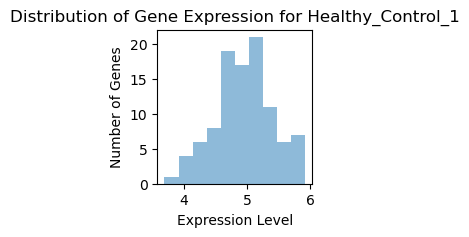

In [71]:
plt.figure(figsize=(2,2))
plt.hist(df["Healthy_Control_1"].values, bins=10, alpha=.5, label='Healthy_Control_1')
plt.xlabel('Expression Level')
plt.ylabel('Number of Genes')
plt.title('Distribution of Gene Expression for Healthy_Control_1')

**Task:** Plot a histogram showcasing the distribution of gene expression levels for `Disease_State_1`.

In [75]:
bins = np.linspace(1,8,20+1)

Text(0.5, 1.0, 'Distribution of Gene Expression for Healthy_Control_1 and Disease_State_1')

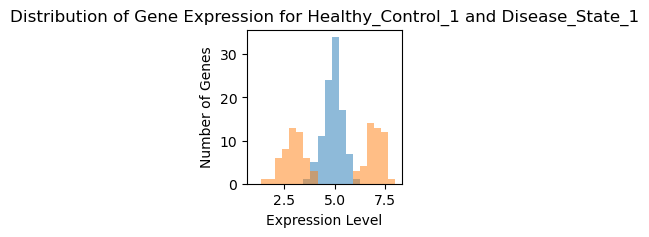

In [76]:
plt.figure(figsize=(2,2))
plt.hist(df["Healthy_Control_1"].values, bins=bins, alpha=.5, label='Healthy_Control_1')
plt.hist(df["Disease_State_1"].values, bins=bins, alpha=.5, label='Disease_State_1')
plt.xlabel('Expression Level')
plt.ylabel('Number of Genes')
plt.title('Distribution of Gene Expression for Healthy_Control_1 and Disease_State_1')

## Boxplot for Comparative Analysis

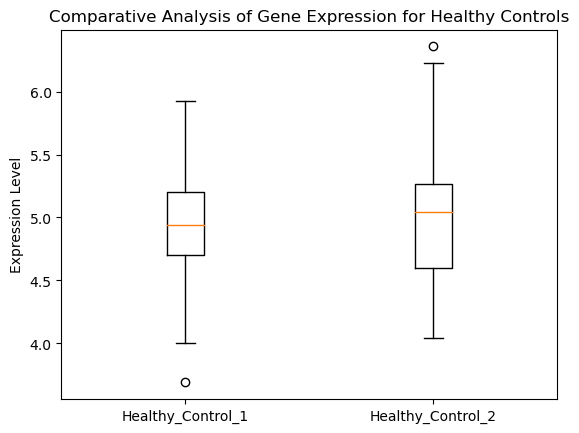

In [77]:
plt.boxplot([df["Healthy_Control_1"].values, df["Healthy_Control_2"].values], labels=["Healthy_Control_1", "Healthy_Control_2"])
plt.ylabel('Expression Level')
plt.title('Comparative Analysis of Gene Expression for Healthy Controls')
plt.show()

**Task**: Create a boxplot to compare the expression distributions between `Disease_State_1` and `Post_Treatment_1`.

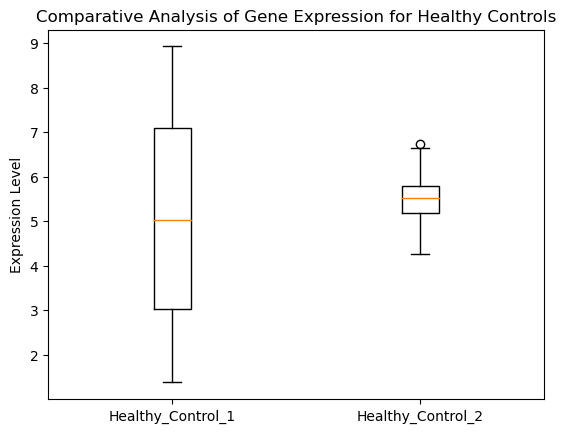

In [101]:
plt.boxplot([df["Disease_State_1"].values, df["Post_Treatment_1"].values], labels=["Healthy_Control_1", "Healthy_Control_2"])
plt.xticks([1,2],["Healthy_Control_1", "Healthy_Control_2"])
plt.ylabel('Expression Level')
plt.title('Comparative Analysis of Gene Expression for Healthy Controls')
plt.show()

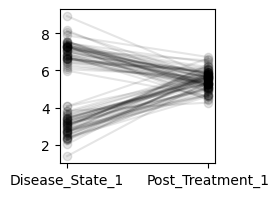

In [89]:
plt.figure(figsize=(2,2))
plt.plot(df[['Disease_State_1', 'Post_Treatment_1']].T, 
         c='k', marker='o', ls='-', alpha=.1);

## Bar Plot for Top Genes

Text(0.5, 1.0, 'Top 5 Expressed Genes in Healthy_Control_1')

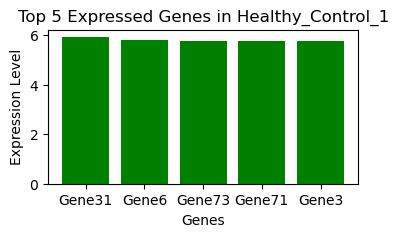

In [93]:
top_genes = df.nlargest(5, 'Healthy_Control_1') 
plt.figure(figsize=(4,2))
plt.bar(top_genes["Gene"], top_genes["Healthy_Control_1"], color='green')
plt.xlabel('Genes')
plt.ylabel('Expression Level')
plt.title('Top 5 Expressed Genes in Healthy_Control_1')

**Task** Plot the top 5 genes with the highest average expression levels using a bar plot.

Text(0.5, 1.0, 'Top 5 Expressed Genes in Average_Expression')

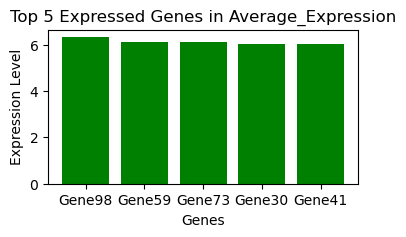

In [95]:
top_genes = df.nlargest(5, 'Average_Expression') 
plt.figure(figsize=(4,2))
plt.bar(top_genes["Gene"], top_genes["Average_Expression"], color='green')
plt.xlabel('Genes')
plt.ylabel('Expression Level')
plt.title('Top 5 Expressed Genes in Average_Expression')

# PRO Tasks

* Create boxplots and show the data distribution as well
* Create a Bland-Altmann-Plot to show differential expression vs. healthy control. Use the both healthy control repetitions to determine the Bland-Altmann-metrics (mean, std), and then add the other conditions

Healthy Control Data

In [59]:
S1 = df["Healthy_Control_1"].values
S2 = df["Healthy_Control_2"].values

x = (S1+S2)/2
y = S1-S2

Some Disease State values

In [63]:
S1_D = df["Healthy_Control_1"].values
S2_D = df["Disease_State_1"].values

x_D = (S1_D+S2_D)/2
y_D = S1_D-S2_D

## 3D Plotting

In [74]:
t = np.linspace(0, 4*np.pi, 200)
x = np.sin(t)
y = np.cos(t)

# Enable 3D view
ax = plt.subplot(111, projection='3d')
plt.plot(x, y, t, ls=":")
# 51, 73
# Set the camera angle with azimuth and elevation
ax.view_init(elev=51, azim=73)

## Excel

Read Excel

Process data somehow

Append a new spreadsheet to an existing Excel-Sheet

In [85]:
with pd.ExcelWriter('Oktoberfest.xlsx', engine="openpyxl", mode="a") as writer:
    df.sum(axis=1).to_excel(writer,sheet_name="Fancy Analysis 2", index=False)

## Images

Writing a single image

Writing gifs

Read images

Converting RGB image to grayscale

Trying to push it into [0, 255], **min-max-scaling**

HxW

Progress bar

Interactive elements in Jupyter notebooks